# Analysis of Car Pricing

### Dataset Overview

The dataset comprises detailed specifications of 205 automobiles across 26 distinct attributes. These include:

- **Vehicle Identifiers**: Attributes like car name and type provide basic identification of each automobile.

- **Technical Specifications**: Includes a comprehensive set of technical data points such as engine size, body style, fuel type, and performance metrics like horsepower and fuel efficiency.


# Study Objectives

1. **Exploration of Influencing Factors**
   - The main aim of the study is to explore multiple factors that affect the prices of cars, identifying key attributes that significantly influence market values.

2. **Model Development**
   - Utilize relevant features from the dataset to build a predictive model that can accurately forecast car prices, integrating statistical and machine learning techniques.

3. **Model Evaluation**
   - Test the effectiveness of various modeling methods by comparing multiple metrics. This involves evaluating the precision,


# Initialize the Data

In [12]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import linear_model
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
car_data = pd.read_csv("data/CarPrice.csv")
car_data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [14]:
print("Number of Rows and Columns")
car_data.shape

Number of Rows and Columns


(205, 26)

In [15]:
print("Information about the Dataset")
car_data.info()

Information about the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize    

## Cleaning the Data

In [17]:
# Check for missing values and duplicates
missing_values = car_data.isnull().sum()
duplicate_values = car_data.duplicated().sum()

# Display results
print(f"Missing Values:\n{missing_values}\n")
print(f"Duplicate Rows: {duplicate_values}")

Missing Values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Duplicate Rows: 0


## Drop columns that are not useful

In [19]:
# Drop irrelevant columns: 'car_ID' and 'CarName'
car_data_cleaned = car_data.drop(['car_ID', 'CarName'], axis=1)

## Encoding Categorical Variables

In [21]:
# Encode categorical variables using one-hot encoding
car_data_cleaned = pd.get_dummies(car_data_cleaned, drop_first=True)
car_data_cleaned.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## Visualize the Data

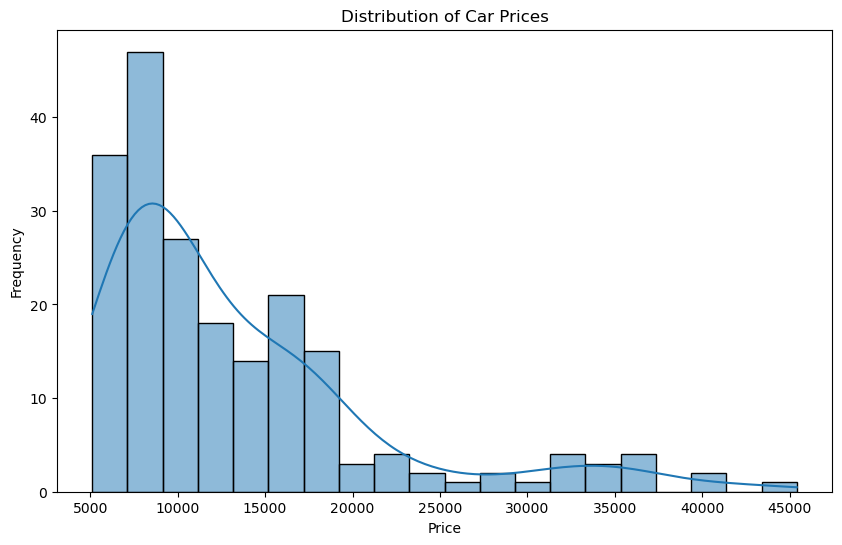

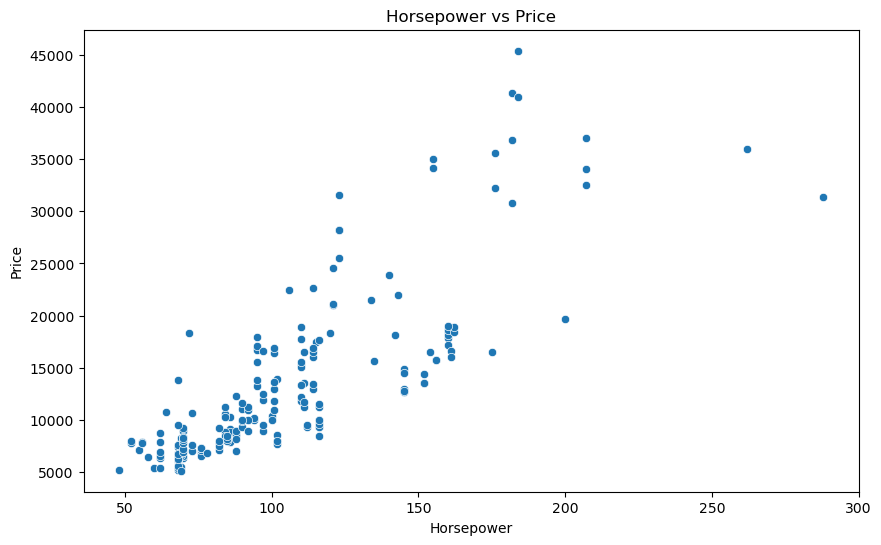

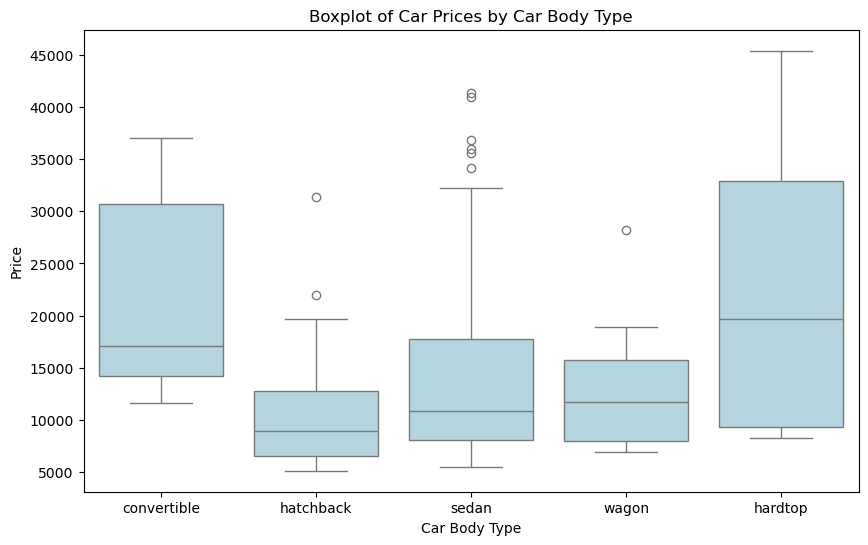

In [23]:
# Plotting the distribution of the target variable (price)
plt.figure(figsize=(10, 6))
sns.histplot(car_data['price'], bins=20, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of Horsepower vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='price', data=car_data)
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.show()

#Boxplot of Price for Different Carbody Types
plt.figure(figsize=(10, 6))
sns.boxplot(x='carbody', y='price', data=car_data, color='lightblue')  # Set color to light blue
plt.title('Boxplot of Car Prices by Car Body Type')
plt.xlabel('Car Body Type')
plt.ylabel('Price')
plt.show()

## Splitting the Dataset for Training and Testing

In [25]:
# Define the target variable (y) and feature variables (X)
X = car_data_cleaned.drop('price', axis=1)
y = car_data_cleaned['price']

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression Model

#### We use the LinearRegression model from sklearn. After fitting the model on the training data (fit()), we predict prices for the test set using predict().

In [28]:
# Run linear regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

# Predict on the test data
y_pred = linear_regressor.predict(X_test)

## Evaluating the Model

In [30]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Show MSE and R-squared
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 8482008.48437166
R-squared (R2): 0.8925566700320263


## Using RFE to determine the best features for a model:

In [32]:
# Initialize the linear regression model
linear_regressor = LinearRegression()

# Use RFE to select the top 10 features
rfe = RFE(estimator=linear_regressor, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Selecting the top features based on RFE
X_train_rfe = X_train.loc[:, rfe.support_]
X_test_rfe = X_test.loc[:, rfe.support_]

# Train a linear regression model using the selected features
linear_regressor_rfe = LinearRegression()
linear_regressor_rfe.fit(X_train_rfe, y_train)

# Predict using the test set with selected features
y_pred_rfe = linear_regressor_rfe.predict(X_test_rfe)

# Evaluate the new model
mse_rfe = mean_squared_error(y_test, y_pred_rfe)
r2_rfe = r2_score(y_test, y_pred_rfe)

print(f"Mean Squared Error (MSE) after RFE: {mse_rfe}")
print(f"R-squared (R2) after RFE: {r2_rfe}")

Mean Squared Error (MSE) after RFE: 33714353.75579191
R-squared (R2) after RFE: 0.572933410534205


### Model Evaluation Metrics

- **MSE (Mean Squared Error)**
  - After implementing Recursive Feature Elimination (RFE), the MSE has increased significantly, indicating a loss in prediction accuracy. The original model had an MSE of approximately 8.48 million, while the post-RFE model exhibits a much higher MSE. This suggests that some critical features may have been removed during the feature selection process, which were pivotal in making accurate predictions.

- **R² (Coefficient of Determination)**
  - The R² value has decreased from 0.89 in the original model to 0.57 in the new model. This drop implies that the new model now explains only 57% of the variance in car prices, compared to the 89% explained previously. This significant reduction highlights the impact of feature elimination on the model's explanatory power and overall effectiveness.


## Training KNN Model

In [35]:
# Initialize the K-Nearest Neighbors Regressor model with 5 neighbors
knn_regressor = KNeighborsRegressor(n_neighbors=5)

knn_regressor.fit(X_train_rfe, y_train)

# Predict on the test data using KNN
y_pred_knn = knn_regressor.predict(X_test_rfe)

# Evaluate the KNN model
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"Mean Squared Error (MSE) with KNN: {mse_knn}")
print(f"R-squared (R2) with KNN: {r2_knn}")

Mean Squared Error (MSE) with KNN: 13135694.251948513
R-squared (R2) with KNN: 0.8336074840680768


In [49]:
# Define the parameter grid to search over (for KNN, we tune 'n_neighbors')
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],  # Test different numbers of neighbors
    
}

# Initialize the K-Nearest Neighbors Regressor model
knn_regressor = KNeighborsRegressor()

# Use GridSearchCV to find the best hyperparameters using 5-fold cross-validation
grid_search = GridSearchCV(estimator=knn_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the training data (using the selected features from RFE)
grid_search.fit(X_train_rfe, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_

# Train a KNN model using the best parameters
best_knn = grid_search.best_estimator_

# Predict on the test data using the best KNN model
y_pred_best_knn = best_knn.predict(X_test_rfe)

# Evaluate the tuned KNN model
mse_best_knn = mean_squared_error(y_test, y_pred_best_knn)
r2_best_knn = r2_score(y_test, y_pred_best_knn)

# Display the best parameters, MSE, and R-squared
print(f"Best Parameters: {best_params}")
print(f"Mean Squared Error (MSE): {mse_best_knn}")
print(f"R-squared (R2): {r2_best_knn}")


Best Parameters: {'n_neighbors': 3}
Mean Squared Error (MSE): 9236788.262831982
R-squared (R2): 0.882995720766332


### KNN Model Performance

- **Performance**: The KNN model with `n_neighbors=3` performs well, achieving an R² of 0.88. This suggests it can explain a large portion of the variance in car prices. However, the MSE still indicates some error in the predictions, pointing to areas where the model may be improved.


## Conclusion

### Can Price Be Predicted?
Car prices can be effectively predicted using the discussed models. The high R-squared values, which are above 0.88, demonstrate that the models are capable of capturing a significant portion of the variability in car prices based on the input features. However, despite the promising R-squared values, there is still room for improvement as suggested by the MSE values.

### Which Model is Better for Price Prediction?
- **Linear Regression**
  - Exhibits slightly better performance in terms of R-squared and MSE compared to KNN. This indicates a more accurate and efficient prediction capability in the current analytical setup.
  
- **KNN (K-Nearest Neighbors)**
  - Provides a different methodological approach, relying on the proximity of local data points rather than assuming a global linear relationship between variables. It performed comparably to linear regression.
  
Both models demonstrate a robust ability to predict car prices with a considerable degree of accuracy. While linear regression has a slight advantage under the current testing conditions, exploring more complex models or further tuning could potentially enhance the accuracy and reliability of predictions.
